1. Start with the existing pretrained checkpoint

Take 100–500 real sequences and do a counterfactual age sweep. Keep the entire patient's events and timestamps fixed, but evaluate the model at ages such as

$$ a\in\{1,5,10,15\}. $$

Save at every age:

$$ \Delta\alpha(a),\quad \alpha(a),\quad \log w_{ij}(a),\quad QK^\top/\sqrt d,\quad A_{ij},\quad h_{\text{final}},\quad \text{output logits}. $$

This gives you a localization test:

Observation                                     	Likely problem
\( \Delta\alpha(a)\) barely changes	                Age encoder / Fourier / MLP never learned age

\(\Delta\alpha\) changes, \(\log w\) doesn't	    Temporal basis or \(\tau\) scaling is killing it

\(\log w\) changes, attention barely changes	    Kernel contribution is too small relative to \(QK\)

Attention changes, representation doesn't	        Residual/content pathway is ignoring it

Representation changes, prediction doesn't	        Pretraining objective does not require the information

Everything changes sensibly	Mechanism works;        downstream task/data may simply not benefit

The saved checkpoints I have, We can validate all, or find the best/ correct one:
From newest to oldest:
1. /home/suraj/Git/Age-conditioned-pediatric-EHR/model_new/run/kernel_s0_072420260946/best.pt
2. /home/suraj/Git/Age-conditioned-pediatric-EHR/checkpoints/age_real_full_20260622/epoch_010.pt
3. /home/suraj/Git/Age-conditioned-pediatric-EHR/checkpoints/age_real_full0504_2130/epoch_010.pt

## Checkpoint 1 — `model_new` kernel arm

Path: `model_new/run/kernel_s0_072420260946/best.pt` (symlink to `epoch_008.pt`).

This is the DKM pretrain model in `model_new/`, arm `kernel`. Age reaches the model on two routes; this test **isolates the kernel route only**:

- **Held fixed:** codes, timestamps, padding, and `demographics` (including the standardized age channel).
- **Swept:** `age_years`, the tensor that feeds `ψ(a) → Δα(a) → log w`.

At every counterfactual age we record the chain

`Δα(a) → α(a) → log w_ij(a) → QKᵀ/√d → A_ij → h → logits`

and stop at the first link that does not move. Layer-0 `QKᵀ/√d` is computed from frozen code embeddings, so it must be age-invariant; a change there is a wiring bug, not a finding.

MIMIC pretraining support starts at ~16.6 y, so `{1, 5, 10, 15}` is extrapolation. The Δα cell also evaluates a few adult ages so we do not confuse “pediatric grid is flat” with “the encoder never learned age”.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import torch
import torch.nn.functional as F

REPO = Path("/home/suraj/Git/Age-conditioned-pediatric-EHR")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from model_new.data import TensorizedPretrainDataset, tau_from_timestamps
from model_new.encoder import build_pair_mask
from model_new.eval_pretrain import build_model, make_val_loader, model_kwargs_from_config

RUN_DIR = REPO / "model_new/run/kernel_s0_072420260946"
CKPT_PATH = RUN_DIR / "best.pt"
AGES = (1.0, 5.0, 10.0, 15.0)
ADULT_AGES = (18.0, 40.0, 65.0, 80.0)
N_SEQ = 128
BATCH_SIZE = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = json.loads((RUN_DIR / "config.json").read_text())
shared = model_kwargs_from_config(cfg)

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
print(f"checkpoint : {CKPT_PATH}")
print(f"  arm={ckpt.get('arm')}  epoch={ckpt.get('epoch')}  seed={ckpt.get('seed')}")
print(f"  tau_max file={ckpt.get('tau_max')}  config={shared['tau_max']}")
if ckpt.get("arm") != "kernel":
    raise RuntimeError(f"expected arm='kernel', got {ckpt.get('arm')!r}")

model = build_model(shared, "kernel")
model.load_state_dict(ckpt["model_state_dict"], strict=True)
model.to(device).eval()
print(f"  device={device}  model.tau_max={float(model.tau_max):.6f}")
print(f"  n_layers={model.n_layers}  n_heads={model.n_heads}  s={model.s}")

ds = TensorizedPretrainDataset(
    REPO / shared["tensorized_dir"] / "val",
    REPO / shared["vocab_path"],
    max_seq_len=shared["max_seq_len"],
)
print(f"  val windows={len(ds):,}  using first {N_SEQ}")
torch.set_grad_enabled(False)


def to_device(batch):
    return {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}


def broadcast_age(batch, age):
    """Replace kernel-site ages only. Demographics (R1) stay at the true values."""
    out = dict(batch)
    mask = batch["attention_mask"].to(dtype=batch["age_years"].dtype)
    out["age_years"] = torch.full_like(batch["age_years"], float(age)) * mask
    return out


def take_sequences(n):
    rows = []
    for batch in make_val_loader(ds, BATCH_SIZE, 0, shared["race_encoding"]):
        rows.append(batch)
        if sum(b["lengths"].shape[0] for b in rows) >= n:
            break
    # trim the last batch so we have exactly n rows
    kept, need = [], n
    for batch in rows:
        bsz = batch["lengths"].shape[0]
        if bsz <= need:
            kept.append(batch)
            need -= bsz
        else:
            kept.append({k: (v[:need] if isinstance(v, torch.Tensor) else v) for k, v in batch.items()})
            need = 0
        if need == 0:
            break
    return kept


checkpoint : /home/suraj/Git/Age-conditioned-pediatric-EHR/model_new/run/kernel_s0_072420260946/best.pt
  arm=kernel  epoch=8  seed=0
  tau_max file=6.72380256652832  config=6.72380256652832
  device=cuda  model.tau_max=6.723803
  n_layers=1  n_heads=1  s=5
  val windows=52,178  using first 128


In [2]:
@torch.no_grad()
def site_curve(site, ages):
    a = torch.tensor(list(ages), dtype=torch.float32, device=device)
    delta = site.age(a)                  # Δα(a)  [A, s]
    alpha = site.alpha_base + delta      # α(a)   [A, s]
    return delta.cpu(), alpha.cpu()


def curve_span(delta):
    """Max pairwise L2 over the age grid. 0 ⇒ Δα does not depend on a."""
    x = delta.float()
    return float(torch.cdist(x, x).max())


print("generator last-layer (W2) and α_base — still-zero W2 means Δα never left init")
for name, site in model.kernel_sites():
    W2 = site.age.generator.mlp[-1].weight.detach()
    print(f"  {name:16s}  ||W2||_F={float(W2.norm()):.4e}  "
          f"α_base={site.alpha_base.detach().cpu().tolist()}")

print("\nΔα(a) and α(a) on the pediatric sweep ages", AGES)
ckpt1_alpha = {}
for name, site in model.kernel_sites():
    delta, alpha = site_curve(site, AGES)
    ckpt1_alpha[name] = {"ages": AGES, "delta_alpha": delta, "alpha": alpha}
    print(f"\n  {name}")
    print(f"    Δα rows (one per age, s={delta.shape[-1]}):")
    for a, d, al in zip(AGES, delta, alpha):
        print(f"      a={a:5.1f}  Δα={d.tolist()}  ||Δα||={float(d.norm()):.4e}  "
              f"α={al.tolist()}")
    print(f"    max pairwise ||Δα(a)-Δα(a')|| = {curve_span(delta):.4e}")

print("\nSame Δα span on adult ages (in-support for this checkpoint)", ADULT_AGES)
for name, site in model.kernel_sites():
    delta, _ = site_curve(site, ADULT_AGES)
    print(f"  {name:16s}  max pairwise ||Δα|| = {curve_span(delta):.4e}")
    for a, d in zip(ADULT_AGES, delta):
        print(f"    a={a:5.1f}  ||Δα||={float(d.norm()):.4e}")


generator last-layer (W2) and α_base — still-zero W2 means Δα never left init
  encoder_layer0    ||W2||_F=3.3685e+00  α_base=[0.17958466708660126, -0.08760899305343628, 0.013723346404731274, -0.07567114382982254, 0.00804488081485033]
  pooling           ||W2||_F=3.6554e+00  α_base=[-0.14649510383605957, 0.009044473990797997, -0.026524905115365982, 0.0646466463804245, -0.015446036122739315]

Δα(a) and α(a) on the pediatric sweep ages (1.0, 5.0, 10.0, 15.0)

  encoder_layer0
    Δα rows (one per age, s=5):
      a=  1.0  Δα=[-4.419120788574219, -1.0288708209991455, 0.8936293125152588, -1.0630139112472534, 4.785155296325684]  ||Δα||=6.7390e+00  α=[-4.239536285400391, -1.1164798736572266, 0.9073526859283447, -1.1386851072311401, 4.7932000160217285]
      a=  5.0  Δα=[-10.600683212280273, -0.24941658973693848, -0.8304070234298706, -1.9987602233886719, 8.838820457458496]  ||Δα||=1.3973e+01  α=[-10.421098709106445, -0.33702558279037476, -0.8166836500167847, -2.0744314193725586, 8.84686565399

In [ ]:
@torch.no_grad()
def encoder_qk(model, batch):
    """Layer-0 QKᵀ/√d. Independent of age: Q,K come from LN(code embeddings)."""
    x = model.embedding_table[batch["code_indices"]]
    blk = model.encoder.blocks[0]
    h_in = blk.ln_attn(x) if blk.ln_attn is not None else x
    attn = blk.attn
    bsz, length, _ = h_in.shape
    q = attn.mlp_q(h_in).view(bsz, length, attn.n_heads, attn.d_head).transpose(1, 2)
    k = attn.mlp_k(h_in).view(bsz, length, attn.n_heads, attn.d_head).transpose(1, 2)
    qk = torch.matmul(q, k.transpose(-1, -2)) * attn.scale
    pair = build_pair_mask(batch["attention_mask"])
    return qk, pair, attn


@torch.no_grad()
def encoder_logw_attn(attn_mod, tau, age_years, qk, pair):
    log_w = attn_mod.kernel(tau, attn_mod.alpha(age_years), count=False)
    pair_h = pair.unsqueeze(1)
    scores = (qk + log_w.unsqueeze(1)).masked_fill(~pair_h, float("-inf"))
    A = torch.softmax(scores, dim=-1).masked_fill(~pair_h, 0.0)
    return log_w, A


def _tv(p, q):
    if p.dim() == 4:
        p, q = p.mean(1), q.mean(1)
    return 0.5 * (p - q).abs().sum(-1)


def _entropy(A):
    if A.dim() == 4:
        A = A.mean(1)
    p = A.clamp_min(1e-12)
    return -(p * p.log()).sum(-1)


@torch.no_grad()
def sweep(model, batches, ages):
    """Counterfactual age sweep. Events/timestamps/demographics fixed."""
    ref_age = ages[0]
    per_age = {a: {"logw_abs": [], "qk_abs": [], "attn_ent": [],
                   "pool_logw_abs": [], "h": [], "logit_mean": [], "logit_std": []}
               for a in ages}
    vs_ref = {a: {"dlogw": [], "dqk": [], "tv": [], "rel_dh": [], "cos_h": [],
                  "dlogit_mean": [], "dlogit_max": [], "R_kernel_over_qk": []}
              for a in ages if a != ref_age}
    true_last_age = []
    n_seen = 0
    example = None

    for batch in batches:
        batch = to_device(batch)
        mask = batch["attention_mask"]
        lengths = batch["lengths"]
        rows = torch.arange(lengths.shape[0], device=device)
        true_last_age.append(batch["age_years"][rows, lengths - 1].cpu())
        tau, _ = tau_from_timestamps(batch["timestamps_days"], mask, lengths)
        qk, pair, attn_mod = encoder_qk(model, batch)

        cache = {}
        for a in ages:
            b_a = broadcast_age(batch, a)
            log_w, A = encoder_logw_attn(attn_mod, tau, b_a["age_years"], qk, pair)
            out = model(b_a, need_diagnostics=True)
            cache[a] = {
                "log_w": log_w, "A": A, "h": out["h"],
                "logits": out["code_logits"],
                "pool_log_w": out["pool_log_w"],
            }
            per_age[a]["logw_abs"].append(log_w[pair].abs().mean().cpu())
            per_age[a]["qk_abs"].append(qk[pair.unsqueeze(1)].abs().mean().cpu())
            per_age[a]["attn_ent"].append(_entropy(A)[mask].mean().cpu())
            per_age[a]["pool_logw_abs"].append(out["pool_log_w"][mask].abs().mean().cpu())
            per_age[a]["h"].append(out["h"].cpu())
            per_age[a]["logit_mean"].append(out["code_logits"].mean().cpu())
            per_age[a]["logit_std"].append(out["code_logits"].std(unbiased=False).cpu())

        if example is None:
            i = 0
            Li = int(lengths[0])
            example = {
                "length": Li,
                "true_age_last": float(batch["age_years"][0, lengths[0] - 1]),
                "by_age": {
                    a: {
                        "log_w_row0": cache[a]["log_w"][0, Li - 1, :Li].cpu(),
                        "qk_row0": qk[0, 0, Li - 1, :Li].cpu(),
                        "A_row0": cache[a]["A"][0, 0, Li - 1, :Li].cpu(),
                        "pool_log_w": cache[a]["pool_log_w"][0, :Li].cpu(),
                    }
                    for a in ages
                },
            }

        ref = cache[ref_age]
        qk_scale = qk[pair.unsqueeze(1)].std(unbiased=False).clamp_min(1e-8)
        for a in ages:
            if a == ref_age:
                continue
            alt = cache[a]
            vs_ref[a]["dlogw"].append((alt["log_w"] - ref["log_w"])[pair].abs().mean().cpu())
            vs_ref[a]["dqk"].append(torch.zeros(()))  # QK computed once; identically 0
            vs_ref[a]["tv"].append(_tv(ref["A"], alt["A"])[mask].mean().cpu())
            dh = alt["h"] - ref["h"]
            vs_ref[a]["rel_dh"].append(
                (dh.norm(dim=-1) / ref["h"].norm(dim=-1).clamp_min(1e-12)).mean().cpu()
            )
            vs_ref[a]["cos_h"].append(F.cosine_similarity(ref["h"], alt["h"], dim=-1).mean().cpu())
            dlogit = (alt["logits"] - ref["logits"]).abs()
            vs_ref[a]["dlogit_mean"].append(dlogit.mean().cpu())
            vs_ref[a]["dlogit_max"].append(dlogit.max().cpu())
            vs_ref[a]["R_kernel_over_qk"].append(
                ((alt["log_w"] - ref["log_w"])[pair].std(unbiased=False) / qk_scale).cpu()
            )
        n_seen += int(lengths.shape[0])
        del cache
        print(f"  processed {n_seen}/{N_SEQ}", flush=True)

    def _cat_mean(xs):
        t = torch.stack([x if x.ndim == 0 else x.mean() for x in xs])
        return float(t.mean())

    summary = {"n": n_seen, "true_age_last": torch.cat(true_last_age).numpy(), "per_age": {}, "vs_ref": {}}
    for a in ages:
        summary["per_age"][a] = {
            "logw_absmean": _cat_mean(per_age[a]["logw_abs"]),
            "qk_absmean": _cat_mean(per_age[a]["qk_abs"]),
            "attn_entropy": _cat_mean(per_age[a]["attn_ent"]),
            "pool_logw_absmean": _cat_mean(per_age[a]["pool_logw_abs"]),
            "h": torch.cat(per_age[a]["h"], dim=0),
            "logit_mean": _cat_mean(per_age[a]["logit_mean"]),
            "logit_std": _cat_mean(per_age[a]["logit_std"]),
        }
    for a, rec in vs_ref.items():
        summary["vs_ref"][a] = {k: _cat_mean(v) for k, v in rec.items()}
    summary["example"] = example
    return summary


batches = take_sequences(N_SEQ)
print(f"running counterfactual sweep on {sum(b['lengths'].shape[0] for b in batches)} sequences, ages={AGES}")
ckpt1_sweep = sweep(model, batches, AGES)
ta = ckpt1_sweep["true_age_last"]
print(f"true last-event age of these windows: min={ta.min():.1f}  median={np.median(ta):.1f}  max={ta.max():.1f}")


In [4]:
# Quantities saved at every sweep age (means over valid pairs / sequences)
print(f"{'a':>6}  {'||Δα||_enc':>12}  {'||Δα||_pool':>12}  {'|log w|':>10}  "
      f"{'|QK/√d|':>10}  {'H(A)':>8}  {'logit μ':>10}")
enc_da = ckpt1_alpha["encoder_layer0"]["delta_alpha"]
pool_da = ckpt1_alpha["pooling"]["delta_alpha"]
for i, a in enumerate(AGES):
    s = ckpt1_sweep["per_age"][a]
    print(f"{a:6.1f}  {float(enc_da[i].norm()):12.4e}  {float(pool_da[i].norm()):12.4e}  "
          f"{s['logw_absmean']:10.4e}  {s['qk_absmean']:10.4e}  {s['attn_entropy']:8.4f}  "
          f"{s['logit_mean']:10.4f}")

print(f"\nPairwise change vs a={AGES[0]:.0f} (events/timestamps/demographics fixed)")
print(f"{'a':>6}  {'mean|Δ log w|':>14}  {'mean TV(A)':>12}  {'rel ||Δh||':>12}  "
      f"{'cos h':>8}  {'mean|Δlogit|':>14}  {'max|Δlogit|':>12}  {'σ(Δlogw)/σ(QK)':>14}")
for a in AGES[1:]:
    r = ckpt1_sweep["vs_ref"][a]
    print(f"{a:6.1f}  {r['dlogw']:14.4e}  {r['tv']:12.4e}  {r['rel_dh']:12.4e}  "
          f"{r['cos_h']:8.5f}  {r['dlogit_mean']:14.4e}  {r['dlogit_max']:12.4e}  "
          f"{r['R_kernel_over_qk']:14.4e}")

da_ped = max(curve_span(v["delta_alpha"]) for v in ckpt1_alpha.values())
da_adult = max(curve_span(site_curve(site, ADULT_AGES)[0]) for _, site in model.kernel_sites())
dlogw = max(r["dlogw"] for r in ckpt1_sweep["vs_ref"].values())
tv = max(r["tv"] for r in ckpt1_sweep["vs_ref"].values())
rel_dh = max(r["rel_dh"] for r in ckpt1_sweep["vs_ref"].values())
dlogit = max(r["dlogit_max"] for r in ckpt1_sweep["vs_ref"].values())
R = max(r["R_kernel_over_qk"] for r in ckpt1_sweep["vs_ref"].values())
qk_moved = max(abs(ckpt1_sweep["per_age"][a]["qk_absmean"] - ckpt1_sweep["per_age"][AGES[0]]["qk_absmean"])
               for a in AGES)

# Walk the markdown table top-to-bottom; first failing link is the localization.
EPS = 1e-3
steps = [
    ("Δα(a) barely changes", da_ped < EPS,
     f"pediatric span={da_ped:.4e}  adult span={da_adult:.4e}",
     "Age encoder / Fourier / MLP never learned age"),
    ("Δα changes, log w doesn't", dlogw < EPS,
     f"mean|Δ log w|={dlogw:.4e}",
     "Temporal basis or τ scaling is killing it"),
    ("log w changes, attention barely changes", tv < EPS,
     f"mean TV(A)={tv:.4e}  σ(Δlogw)/σ(QK)={R:.4e}",
     "Kernel contribution is too small relative to QK"),
    ("Attention changes, representation doesn't", rel_dh < EPS,
     f"rel ||Δh||={rel_dh:.4e}",
     "Residual/content pathway is ignoring it"),
    ("Representation changes, prediction doesn't", dlogit < EPS,
     f"max|Δlogit|={dlogit:.4e}",
     "Pretraining objective does not require the information"),
]

print("\nLocalization")
print(f"  QK age-invariance check (must be ~0): {qk_moved:.4e}")
hit = None
for obs, failed, number, cause in steps:
    flag = "FAIL" if failed else "ok  "
    print(f"  [{flag}] {obs:48s}  {number}")
    if failed and hit is None:
        hit = (obs, cause)
if hit is None:
    print("\n  Verdict: every link in the chain moves. The kernel path is not dead.")
else:
    print(f"\n  Verdict: {hit[0]}")
    print(f"  Likely problem: {hit[1]}")
if da_ped < EPS <= da_adult:
    print("  Note: Δα is flat on {1,5,10,15} but moves on adult ages.")
    print("  That is extrapolation off MIMIC support (~16.6 y+), not a dead generator.")
elif da_ped > 2.0 * max(da_adult, EPS):
    print("  Note: pediatric ||Δα|| span is much larger than the adult span.")
    print("  {1,5,10,15} is off the MIMIC support; large motion here is extrapolation,")
    print("  not evidence that a developmental kernel was learned in the pediatric range.")


     a    ||Δα||_enc   ||Δα||_pool     |log w|     |QK/√d|      H(A)     logit μ
   1.0    6.7390e+00    6.9509e+00  3.0835e+00  3.4024e+00    2.8162    -12.3513
   5.0    1.3973e+01    1.3661e+01  5.2766e+00  3.4024e+00    2.4846    -12.5363
  10.0    4.5449e+00    6.0607e+00  2.5061e+00  3.4024e+00    3.0214    -12.4173
  15.0    1.4954e+00    2.3629e+00  8.8831e-01  3.4024e+00    3.5360    -12.3158

Pairwise change vs a=1 (events/timestamps/demographics fixed)
     a   mean|Δ log w|    mean TV(A)    rel ||Δh||     cos h    mean|Δlogit|   max|Δlogit|  σ(Δlogw)/σ(QK)
   5.0      3.9965e+00    2.4372e-01    3.8378e-01   0.91717      6.8780e-01    5.5238e+00      1.0746e+00
  10.0      8.3784e-01    1.1935e-01    2.0174e-01   0.97183      3.6300e-01    2.9589e+00      2.7021e-01
  15.0      3.8869e+00    6.9258e-01    5.0340e-01   0.81938      8.4561e-01    6.8705e+00      1.1948e+00

Localization
  QK age-invariance check (must be ~0): 0.0000e+00
  [ok  ] Δα(a) barely changes          

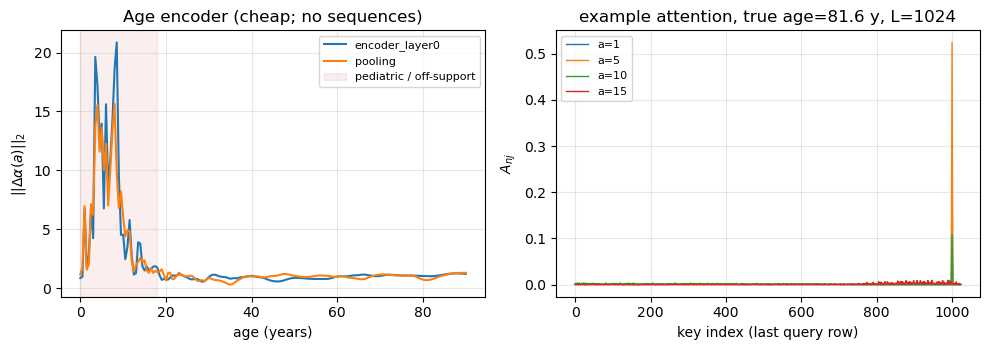

In [5]:
import matplotlib.pyplot as plt

grid = np.round(np.arange(0.0, 90.25, 0.5), 4)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

ax = axes[0]
for name, site in model.kernel_sites():
    delta, _ = site_curve(site, grid)
    ax.plot(grid, delta.norm(dim=-1).numpy(), label=name)
ax.axvspan(0, 18, color="C3", alpha=0.08, label="pediatric / off-support")
ax.set_xlabel("age (years)")
ax.set_ylabel(r"$||\Delta\alpha(a)||_2$")
ax.set_title("Age encoder (cheap; no sequences)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ex = ckpt1_sweep["example"]
for a in AGES:
    ax.plot(ex["by_age"][a]["A_row0"].numpy(), label=f"a={a:.0f}", lw=1)
ax.set_xlabel("key index (last query row)")
ax.set_ylabel(r"$A_{n j}$")
ax.set_title(f"example attention, true age={ex['true_age_last']:.1f} y, L={ex['length']}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


2. Check whether gradients ever reached the age pathway

On a few batches from your existing training setup, log gradient norms for:

$$ \text{age input} \rightarrow \text{Fourier} \rightarrow \text{age MLP} \rightarrow \Delta\alpha \rightarrow \log w. $$

Compare them against gradients in \(Q,K,V\), FFN, and the prediction head.

You want to answer:

Is the optimizer actually getting a meaningful signal telling it how age should change temporal weighting?

In [6]:
from model_new.optim import build_param_groups
from model_new import diagnostics as D

N_PROBE = 8
PROBE_BS = 2
lrs = cfg["optim"]
groups, group_report = build_param_groups(
    model, lrs["lr_backbone"], lrs["lr_age"], lrs["lr_head"])
id_to_group = {id(p): g["name"] for g in groups for p in g["params"]}
print("optimizer groups (declared membership, not name matching)")
print(f"  tensors={group_report['n_tensors']}  params={group_report['n_params']}")
print(f"  lr={ {k: lrs[k] for k in ('lr_backbone','lr_age','lr_head')} }")

# α_base is a kernel coefficient but NOT in the age group — call that out.
print("\nα_base group (should be backbone):")
for name, p in model.named_parameters():
    if name.endswith("alpha_base"):
        print(f"  {name:40s}  group={id_to_group.get(id(p), '?')}")


def _group_stats(groups):
    out = {}
    for g in groups:
        sq = n = n_ok = 0.0
        for p in g["params"]:
            n += p.numel()
            if p.grad is None:
                continue
            sq += float(p.grad.detach().double().pow(2).sum())
            n_ok += p.numel()
        l2 = sq ** 0.5
        out[g["name"]] = {
            "l2": l2,
            "rms": (l2 / (n ** 0.5)) if n else 0.0,
            "n": int(n),
            "n_with_grad": int(n_ok),
        }
    return out


def _tensor_rows():
    rows = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        grp = id_to_group.get(id(p), "?")
        if grp != "age" and not name.endswith("alpha_base"):
            continue
        g = p.grad
        if g is None:
            rows.append((name, grp, float("nan"), float("nan"), 0.0, int(p.numel())))
            continue
        gd = g.detach().float()
        l2 = float(gd.norm())
        rms_g = float(gd.pow(2).mean().sqrt())
        rms_p = float(p.detach().float().pow(2).mean().sqrt())
        frac = float((gd.abs() > 1e-12).float().mean())
        rows.append((name, grp, l2, rms_g / max(rms_p, 1e-12), frac, int(p.numel())))
    return rows


# Per-batch probe: one backward each, so we can see if age/backbone is consistently tiny.
torch.set_grad_enabled(True)
model.eval()
probe_loader = make_val_loader(ds, PROBE_BS, 0, shared["race_encoding"])
per_batch = []
last_rows = None
for i, batch in enumerate(probe_loader, 1):
    if i > N_PROBE:
        break
    batch = to_device(batch)
    model.zero_grad(set_to_none=True)
    out = model(batch)
    loss = F.binary_cross_entropy_with_logits(out["code_logits"].float(),
                                              batch["target_codes"].float())
    loss.backward()
    st = _group_stats(groups)
    st["loss"] = float(loss.detach())
    bb = st["backbone"]["rms"]
    st["age_over_backbone_l2"] = st["age"]["l2"] / st["backbone"]["l2"] if st["backbone"]["l2"] else float("nan")
    st["age_over_backbone_rms"] = st["age"]["rms"] / bb if bb else float("nan")
    per_batch.append(st)
    last_rows = _tensor_rows()
    print(f"  batch {i:02d}  loss={st['loss']:.5f}  "
          f"||g|| age/bb/head={st['age']['l2']:.3e}/{st['backbone']['l2']:.3e}/{st['head']['l2']:.3e}  "
          f"RMS age/bb={st['age']['rms']:.3e}/{st['backbone']['rms']:.3e}  "
          f"age/bb L2={st['age_over_backbone_l2']:.3e}  RMS={st['age_over_backbone_rms']:.3e}")

# Pooled probe (mean loss over the same K batches) — matches eval_pretrain.gradient_probe.
# Fresh loader: shuffle=False, so this is the same first N_PROBE batches.
probe_loader = make_val_loader(ds, PROBE_BS, 0, shared["race_encoding"])
model.zero_grad(set_to_none=True)
n_used = 0
for i, batch in enumerate(probe_loader, 1):
    if i > N_PROBE:
        break
    batch = to_device(batch)
    out = model(batch)
    loss = F.binary_cross_entropy_with_logits(out["code_logits"].float(),
                                              batch["target_codes"].float())
    (loss / N_PROBE).backward()
    n_used += 1
pooled = _group_stats(groups)
gen = D.generator_gradient_fractions(model)
pooled_rows = _tensor_rows()

def _bucket(name):
    if "age.generator" in name:
        return "age MLP (Δα)"
    if name.endswith("alpha_base"):
        return "alpha_base"
    if ".attn.mlp_q" in name:
        return "Q"
    if ".attn.mlp_k" in name:
        return "K"
    if ".attn.mlp_v" in name:
        return "V"
    if ".ffn." in name:
        return "FFN"
    if name.startswith("head."):
        return "head"
    if name.startswith("demo_proj"):
        return "demo_proj (R1)"
    return None

bucket_sq, bucket_n = {}, {}
for name, p in model.named_parameters():
    b = _bucket(name)
    if b is None or p.grad is None:
        continue
    bucket_sq[b] = bucket_sq.get(b, 0.0) + float(p.grad.detach().double().pow(2).sum())
    bucket_n[b] = bucket_n.get(b, 0) + p.numel()

model.zero_grad(set_to_none=True)
torch.set_grad_enabled(False)

print(f"\npooled over {n_used} batches (mean BCE)")
for name in ("backbone", "age", "head"):
    s = pooled[name]
    print(f"  {name:10s}  ||g||_2={s['l2']:.4e}  RMS={s['rms']:.4e}  n={s['n']}")
print(f"  age/backbone  L2={pooled['age']['l2']/pooled['backbone']['l2']:.4e}  "
      f"RMS={pooled['age']['rms']/pooled['backbone']['rms']:.4e}")

print("\nFourier has no trainable params (fixed frequencies). Module RMS vs age MLP:")
print(f"  {'module':18s} {'n':>8s} {'||g||_2':>12s} {'RMS':>12s} {'RMS / ageMLP':>14s}")
age_rms = (bucket_sq.get('age MLP (Δα)', 0.0) / max(bucket_n.get('age MLP (Δα)', 1), 1)) ** 0.5
order = ["age MLP (Δα)", "alpha_base", "Q", "K", "V", "FFN", "demo_proj (R1)", "head"]
for b in order:
    if b not in bucket_n:
        continue
    l2 = bucket_sq[b] ** 0.5
    rms = (bucket_sq[b] / bucket_n[b]) ** 0.5
    rel = rms / age_rms if age_rms else float("nan")
    print(f"  {b:18s} {bucket_n[b]:8d} {l2:12.4e} {rms:12.4e} {rel:14.3e}")

print("\ngenerator nonzero-grad fraction (dead if 0 at a trained checkpoint)")
for site, g in gen.items():
    print(f"  {site:16s}  frac>|0|={g['frac_nonzero_grad_gt_0']:.3f}  "
          f"frac>|1e-12|={g['frac_nonzero_grad_gt_1e-12']:.3f}  "
          f"||g||={g['grad_l2']:.4e}  dead={g['zero_gradient_at_trained_checkpoint']}")

print("\nage-group tensors + α_base  (pooled)")
print(f"  {'name':48s} {'grp':8s} {'||g||':>10s} {'rms(g)/rms(p)':>14s} {'frac>1e-12':>10s}")
for name, grp, l2, ratio, frac, n in pooled_rows:
    print(f"  {name:48s} {grp:8s} {l2:10.3e} {ratio:14.3e} {frac:10.3f}")


optimizer groups (declared membership, not name matching)
  tensors={'backbone': 20, 'age': 6, 'head': 4}  params={'backbone': 1578378, 'age': 4864, 'head': 10091335}
  lr={'lr_backbone': 0.0002, 'lr_age': 0.002, 'lr_head': 0.002}

α_base group (should be backbone):
  encoder.blocks.0.attn.alpha_base          group=backbone
  pooling.alpha_base                        group=backbone
  batch 01  loss=0.00993  ||g|| age/bb/head=2.496e-04/1.837e-02/2.432e-03  RMS age/bb=3.578e-06/1.462e-05  age/bb L2=1.359e-02  RMS=2.447e-01
  batch 02  loss=0.00775  ||g|| age/bb/head=1.113e-04/1.889e-02/2.316e-03  RMS age/bb=1.595e-06/1.503e-05  age/bb L2=5.891e-03  RMS=1.061e-01
  batch 03  loss=0.00782  ||g|| age/bb/head=1.325e-04/2.317e-02/2.421e-03  RMS age/bb=1.899e-06/1.844e-05  age/bb L2=5.716e-03  RMS=1.030e-01
  batch 04  loss=0.00688  ||g|| age/bb/head=1.944e-04/2.039e-02/2.513e-03  RMS age/bb=2.788e-06/1.623e-05  age/bb L2=9.533e-03  RMS=1.717e-01
  batch 05  loss=0.00616  ||g|| age/bb/head=7.3

In [7]:
# Historical signal: did Adam actually move the age group?
train_recs = json.loads((RUN_DIR / "train.json").read_text())
print(f"{'ep':>4}  {'val_loss':>10}  {'drift_bb':>10}  {'drift_age':>10}  {'drift_head':>10}  "
      f"{'||Δα||_enc':>10}  {'varying':>10}")
for r in train_recs:
    a = r["alpha"]["encoder_layer0"]
    d = r["param_drift"]
    mark = "  <-- best.pt" if int(r["epoch"]) == int(ckpt.get("epoch", -1)) else ""
    print(f"{r['epoch']:4d}  {r['val_loss']:10.6f}  {d['backbone']:10.4f}  {d['age']:10.4f}  "
          f"{d['head']:10.4f}  {a['delta_alpha_norm_mean']:10.4f}  {a['varying_component']:10.4f}{mark}")

# Adam |m̂|/√v̂ from the checkpoint optimizer state — the step direction, before lr.
osd = ckpt["optimizer_state_dict"]
flat = []
for g in groups:
    for p in g["params"]:
        n = next(n for n, q in model.named_parameters() if q is p)
        flat.append((g["name"], n, p))
# state_dict param indices follow the same group order Adam saw at train time.
beta1, beta2, eps = 0.9, 0.999, 1e-8
print(f"\nAdam signal at epoch {ckpt.get('epoch')}  (bias-corrected |m̂| / (√v̂+eps), mean over tensor)")
print(f"  {'group':10s} {'name':48s} {'step':>8s} {'rms |m̂|/√v̂':>12s} {'rms |m|':>10s}")
adam_rms = {"backbone": [], "age": [], "head": []}
for i, (grp, name, p) in enumerate(flat):
    st = osd["state"].get(i, osd["state"].get(str(i)))
    step = int(st["step"].item() if torch.is_tensor(st["step"]) else st["step"])
    m = st["exp_avg"].float()
    v = st["exp_avg_sq"].float()
    mhat = m / (1.0 - beta1 ** step)
    vhat = v / (1.0 - beta2 ** step)
    sig = (mhat.abs() / (vhat.sqrt() + eps))
    rms = float(sig.pow(2).mean().sqrt())
    rms_m = float(m.pow(2).mean().sqrt())
    adam_rms[grp].append(rms)
    if grp == "age" or name.endswith("alpha_base"):
        print(f"  {grp:10s} {name:48s} {step:8d} {rms:12.4e} {rms_m:10.4e}")

print("\nAdam |m̂|/√v̂  mean over tensors in group:")
for grp, vals in adam_rms.items():
    print(f"  {grp:10s}  {float(np.mean(vals)):.4e}")

# Consistency of the live probe.
l2_ratios = np.array([s["age_over_backbone_l2"] for s in per_batch])
rms_ratios = np.array([s["age_over_backbone_rms"] for s in per_batch])
print(f"\nlive probe over {len(per_batch)} batches")
print(f"  age/backbone ||g||_2 : median={np.median(l2_ratios):.3e}  "
      f"min={l2_ratios.min():.3e}  max={l2_ratios.max():.3e}")
print(f"  age/backbone RMS     : median={np.median(rms_ratios):.3e}  "
      f"min={rms_ratios.min():.3e}  max={rms_ratios.max():.3e}")

# Localization.
dead = any(g["zero_gradient_at_trained_checkpoint"] for g in gen.values())
age_tiny_l2 = np.median(l2_ratios) < 1e-2
age_tiny_rms = np.median(rms_ratios) < 1e-2
best_ep = int(ckpt.get("epoch", train_recs[-1]["epoch"]))
drift_at = next(r["param_drift"] for r in train_recs if int(r["epoch"]) == best_ep)
age_moved = drift_at["age"] is not None and drift_at["age"] > 0.1
print("\nVerdict")
if dead:
    print("  Age generator has zero gradient at this checkpoint — pathway is dead.")
elif age_tiny_l2 and not age_tiny_rms:
    print("  Raw age ||g||_2 is much smaller than backbone, but that is mostly group size")
    print("  (4.8k vs 1.6M params). Per-parameter RMS is not orders of magnitude smaller.")
elif age_tiny_rms:
    print("  Age-branch gradients are consistently orders of magnitude smaller per parameter.")
else:
    print("  Age-branch gradients are NOT consistently orders of magnitude smaller")
    print("  once you compare RMS (per-parameter), not raw L2.")
if age_moved:
    print(f"  Optimizer DID get a signal: age-group drift at epoch {best_ep} is "
          f"{drift_at['age']:.3f} vs backbone {drift_at['backbone']:.3f}.")
    print("  (Age LR is 10× backbone; Adam will step even on a small gradient.)")
else:
    print("  Age-group parameter drift is ~0 — optimizer did not move the age branch.")
if drift_at["age"] > drift_at["backbone"] and any(
        r["alpha"]["encoder_layer0"]["varying_component"]
        < 0.5 * r["alpha"]["encoder_layer0"]["constant_component"]
        for r in train_recs if int(r["epoch"]) == best_ep):
    print("  Caveat: most of the learned Δα is an age-invariant offset (constant ≫ varying).")
    print("  Drift ≠ a developmental age signal.")


  ep    val_loss    drift_bb   drift_age  drift_head  ||Δα||_enc     varying
   1    0.010309      0.2692      1.1066      0.2060      0.7083      0.3585
   2    0.010200      0.3774      1.5664      0.2953      0.8078      0.3555
   3    0.009942      0.4597      2.0268      0.3638      0.9021      0.2436
   4    0.009954      0.5287      2.4904      0.4218      0.8104      0.2220
   5    0.009915      0.5883      2.8274      0.4733      0.9080      0.2477
   6    0.009837      0.6429      3.0975      0.5200      0.9823      0.2785
   7    0.009888      0.6923      3.3256      0.5628      1.0786      0.2382
   8    0.009909      0.7394      3.5587      0.6034      0.9515      0.2342  <-- best.pt
   9    0.009985      0.7844      3.7225      0.6413      0.9786      0.2883
  10    0.010075      0.8269      3.8696      0.6772      0.8521      0.2692
  11    0.010139      0.8674      4.0133      0.7124      0.9461      0.2222

Adam signal at epoch 8  (bias-corrected |m̂| / (√v̂+eps), mean

3. Evaluate the MIMIC validation loss under four settings:

Full DKM

$$ \alpha(a)=\alpha_{\text{base}}+\Delta\alpha(a) $$
Constant-age DKM
Replace every patient's age with one fixed adult age, e.g. the training-set mean.

Mean-\(\Delta\alpha\) DKM
Compute

$$ \bar{\Delta\alpha}=E_a[\Delta\alpha(a)] $$

and use it for everybody.

Shuffle ages
Randomly permute ages between patients while leaving their clinical sequences unchanged.

This directly tests what we actually care about.

If:

$$ L_{\text{full}} \approx L_{\text{constant}} \approx L_{\text{shuffle}}, $$

then you have very strong evidence that pretraining learned to use the temporal kernel, but not the association between age and temporal relevance.

In [ ]:
from model_new.diagnostics import bce_totals, recall_per_example

# Same val protocol the run logged: batch-mean BCE, then mean over batches.
# Config used batch_size=64, val_max_batches=50.
EVAL_BS = int(cfg["optim"]["batch_size"])
N_BATCHES = int(cfg["optim"].get("val_max_batches", 50))
if N_BATCHES <= 0:
    N_BATCHES = 50
AGE_MEAN = float(shared["age_mean"])
SHUFFLE_SEED = 0

torch.set_grad_enabled(False)
model.eval()

# Collect the eval batches once so all four settings see the same sequences.
eval_batches = []
for i, batch in enumerate(make_val_loader(ds, EVAL_BS, 0, shared["race_encoding"]), 1):
    if i > N_BATCHES:
        break
    eval_batches.append({k: (v.contiguous() if isinstance(v, torch.Tensor) else v)
                         for k, v in batch.items()})
n_seq = sum(b["lengths"].shape[0] for b in eval_batches)
print(f"eval set: {len(eval_batches)} batches, {n_seq} sequences, batch_size={EVAL_BS}")
print(f"training-set mean age (config age_standardization.mean) = {AGE_MEAN:.6f} y")
print("intervention: age_years only (kernel input). codes, timestamps, demographics unchanged.")


def _constant_age(batch, age):
    out = dict(batch)
    mask = batch["attention_mask"].to(dtype=batch["age_years"].dtype)
    out["age_years"] = torch.full_like(batch["age_years"], float(age)) * mask
    return out


def _split_shuffled_ages(batches, seed):
    """Permute patients' valid age trajectories. Codes/timestamps/mask stay put.

    Donor ages are written onto the recipient's valid slots, most-recent-aligned:
    if the donor is longer, keep the last L_recip ages; if shorter, fill the older
    slots with the donor's earliest age. Padding stays 0.
    """
    donors = []
    for b in batches:
        for i in range(int(b["lengths"].shape[0])):
            L = int(b["lengths"][i])
            donors.append(b["age_years"][i, :L].clone())
    perm = np.random.default_rng(seed).permutation(len(donors))
    out = [b["age_years"].clone() for b in batches]
    n_mismatch = 0
    k = 0
    for bi, b in enumerate(batches):
        for i in range(int(b["lengths"].shape[0])):
            L = int(b["lengths"][i])
            d = donors[int(perm[k])]
            Ld = int(d.numel())
            if Ld != L:
                n_mismatch += 1
            if Ld >= L:
                filled = d[-L:]
            else:
                filled = torch.empty(L, dtype=d.dtype)
                filled[: L - Ld] = d[0]
                filled[L - Ld :] = d
            out[bi][i, :L] = filled
            if L < out[bi].shape[1]:
                out[bi][i, L:] = 0
            k += 1
    return out, n_mismatch, len(donors)


@torch.no_grad()
def _mean_delta_vectors(batches):
    event_ages, last_ages = [], []
    for b in batches:
        mask = b["attention_mask"]
        event_ages.append(b["age_years"][mask])
        n = b["lengths"]
        rows = torch.arange(n.shape[0])
        last_ages.append(b["age_years"][rows, n - 1])
    event_ages = torch.cat(event_ages).to(device)
    last_ages = torch.cat(last_ages).to(device)
    out = {}
    for name, site in model.kernel_sites():
        a = last_ages if name == "pooling" else event_ages
        out[name] = site.age(a).mean(dim=0).detach()
    return out, event_ages.shape[0], last_ages.shape[0]


@torch.no_grad()
def _eval(batches, *, age_override=None, shuffled_ages=None, mean_delta=None):
    hooks = []
    if mean_delta is not None:
        for name, site in model.kernel_sites():
            vec = mean_delta[name]

            def _hook(_mod, _inp, output, d=vec):
                return d.to(device=output.device, dtype=output.dtype).expand_as(output)

            hooks.append(site.age.register_forward_hook(_hook))
    per_seq, r10 = [], []
    batch_means = []
    try:
        for i, batch in enumerate(batches):
            b = dict(batch)
            if age_override is not None:
                b = _constant_age(b, age_override)
            if shuffled_ages is not None:
                b = dict(b)
                b["age_years"] = shuffled_ages[i]
            b = to_device(b)
            logits = model(b)["code_logits"].float()
            targets = b["target_codes"].float()
            seq_sum, n_codes = bce_totals(logits, targets)
            per_seq.append(seq_sum / n_codes)
            batch_means.append(float((seq_sum / n_codes).mean()))
            r10.append(recall_per_example(logits, targets, ks=(10,))[10])
    finally:
        for h in hooks:
            h.remove()
    seq = torch.cat(per_seq)
    rec = torch.cat(r10)
    return {
        "n": int(seq.numel()),
        "bce_element_mean": float(seq.mean()),  # mean of per-sequence means = mean over seq of mean over codes
        "bce_batch_mean": float(np.mean(batch_means)),  # train.py val_loss
        "bce_seq": seq.numpy(),
        "recall@10": float(rec.mean()),
        "bce_seq_std": float(seq.std(unbiased=True)),
    }


mean_delta, n_event, n_last = _mean_delta_vectors(eval_batches)
print(f"\nmean Δα from this eval set ({n_event} event ages, {n_last} last-event ages)")
a_mean_t = torch.tensor([AGE_MEAN], device=device)
for name, site in model.kernel_sites():
    d_bar = mean_delta[name].cpu()
    d_at_mean = site.age(a_mean_t).detach().cpu().squeeze(0)
    print(f"  {name}")
    print(f"    E_a[Δα]     = {d_bar.tolist()}   ||.||={float(d_bar.norm()):.4f}")
    print(f"    Δα(ā={AGE_MEAN:.2f}) = {d_at_mean.tolist()}   ||.||={float(d_at_mean.norm()):.4f}")

shuffled, n_mismatch, n_patients = _split_shuffled_ages(eval_batches, SHUFFLE_SEED)
print(f"\nshuffle: permute valid age trajectories across {n_patients} patients, seed={SHUFFLE_SEED}")
print(f"  donor/recipient length mismatches (most-recent aligned): {n_mismatch}/{n_patients}")

settings = [
    ("full", dict()),
    ("constant_age", dict(age_override=AGE_MEAN)),
    ("mean_delta", dict(mean_delta=mean_delta)),
    ("shuffle", dict(shuffled_ages=shuffled)),
]

results = {}
for name, kw in settings:
    print(f"running {name}...", flush=True)
    results[name] = _eval(eval_batches, **kw)

print(f"\n{'setting':16s}  {'n':>6s}  {'val_loss (batch-mean)':>22s}  "
      f"{'per-seq BCE':>12s}  {'std':>10s}  {'recall@10':>10s}")
for name, _ in settings:
    r = results[name]
    print(f"{name:16s}  {r['n']:6d}  {r['bce_batch_mean']:22.8f}  "
          f"{r['bce_element_mean']:12.8f}  {r['bce_seq_std']:10.6f}  {r['recall@10']:10.6f}")

full = results["full"]["bce_seq"]
print(f"\npaired Δ BCE vs full  (same {len(full)} sequences; SE = std(Δ)/sqrt(n))")
print(f"{'setting':16s}  {'mean Δ':>12s}  {'SE':>10s}  {'median Δ':>12s}  "
      f"{'|Δ|/SE':>8s}  {'frac seq Δ>0':>12s}")
for name, _ in settings:
    if name == "full":
        continue
    d = results[name]["bce_seq"] - full
    se = float(d.std(ddof=1) / np.sqrt(len(d)))
    print(f"{name:16s}  {float(d.mean()):12.8f}  {se:10.8f}  {float(np.median(d)):12.8f}  "
          f"{abs(float(d.mean())) / se if se else float('nan'):8.2f}  {float((d > 0).mean()):12.4f}")

print("\ntrain.json val_loss at this checkpoint epoch "
      f"{ckpt.get('epoch')}: "
      f"{next((r['val_loss'] for r in json.loads((RUN_DIR/'train.json').read_text()) if int(r['epoch'])==int(ckpt.get('epoch',-1))), float('nan')):.8f}")


eval set: 50 batches, 3200 sequences, batch_size=64
training-set mean age (config age_standardization.mean) = 63.336010 y
intervention: age_years only (kernel input). codes, timestamps, demographics unchanged.

mean Δα from this eval set (1546348 event ages, 3200 last-event ages)
  encoder_layer0
    E_a[Δα]     = [0.46797317266464233, 0.060890186578035355, 0.39963027834892273, 0.07157736271619797, 0.11242466419935226]   ||.||=0.6326
    Δα(ā=63.34) = [1.0017356872558594, -0.17600542306900024, 0.0531645193696022, -0.28943926095962524, -0.11238046735525131]   ||.||=1.0647
  pooling
    E_a[Δα]     = [-0.7469062805175781, -0.46918925642967224, -0.30070871114730835, 0.04900818690657616, -0.11231757700443268]   ||.||=0.9399
    Δα(ā=63.34) = [-0.6851345896720886, -0.4221758544445038, -0.28032535314559937, 0.08658207207918167, -0.12176802009344101]   ||.||=0.8652

shuffle: permute valid age trajectories across 3200 patients, seed=0
  donor/recipient length mismatches (most-recent aligned): 

: 